<a href="https://colab.research.google.com/github/MayEmefaFafa/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [326]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [327]:
taxi = pd.read_csv(TAXI_URL)

In [328]:
taxi.shape

(41202, 13)

In [329]:
taxi.head()


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [330]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [331]:
taxi.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


In [332]:
taxi.isna().sum()

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


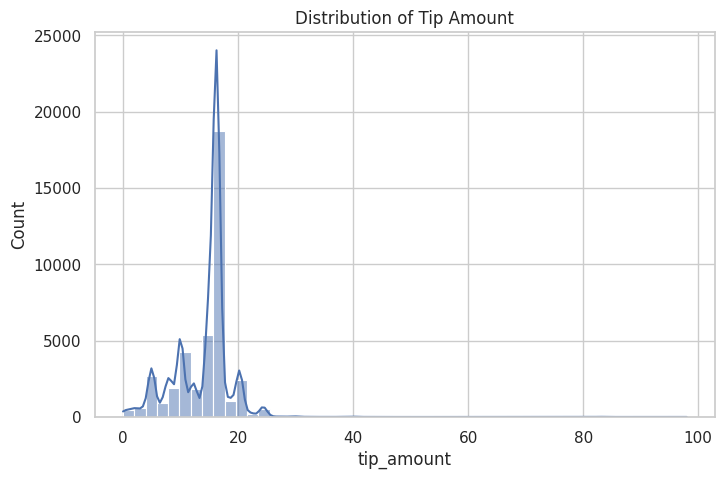

In [333]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(taxi["tip_amount"], bins=50, kde=True)
plt.title("Distribution of Tip Amount")
plt.show()

The tip amount distribution is not perfectly symmetric. It can be described as right skewed with a strong central peak and a tail to the right, implying that there are higher value outliers. The dataset has no missing values in any column as all variables have 41,202 non-null entries.However, it is still vital to check for invalid or unrealistic values. These features will influence preprocessing in ways as followss:
a. Handling of outliers.
b. Validating unrealistic trip records and applying transformation techniques.

In [334]:
taxi = taxi.dropna()

In [335]:
taxi = taxi[(taxi["trip_distance"] > 0) & (taxi["fare_amount"] > 0)]

In [336]:
taxi = taxi[taxi["tip_amount"] >= 0]

In [337]:
taxi = taxi[taxi["tip_amount"] >= 0]

In [338]:
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

In [339]:
taxi = taxi.replace([np.inf, -np.inf], np.nan)
taxi = taxi.dropna()

In [340]:
X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]

In [341]:
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag"
]

In [342]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [343]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Missing rows were handled by first checking for missing values and confirming that none existed in the dataset. After that, invalid recors were removed because they could distort the learning process of the model.
2. New features, fare_per_mile and total_surcharges were engineered by dividing (fare_amount by trip_distance) and summation of (mta_tax, tolls_amount and improvement_surcharge) respectively so the efficiency of a trip can be captured and also assist the model to understand the full cost structure of a trip beyond just the base fare hence the "total_surcharges".
3. The StandardScaler method was chosen for scaling numerical features because it standardizes the data by removing the mean and scaling to unit variance.This is appropriate here because the dataset contains features with different units and scales.

In [344]:
X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]

In [345]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [346]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE
)

In [347]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

I used 60% of the data for training, 20% for validation and 20% for testing. A validation test is useful because it ensures that the test set remains a completely unbiased evaluation of the final model's performance.
The scaler (and any imputation statistics) must fit only on the training data to avoid data leakage. Using the full dataset would indirectly influence the model training.

In [348]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [349]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [350]:
lr_train_pred = lr.predict(X_train_scaled)
lr_val_pred = lr.predict(X_val_scaled)
lr_test_pred = lr.predict(X_test_scaled)

In [351]:
rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

In [352]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

In [353]:
print("Linear Regression")
print("Train:", evaluate(y_train, lr_train_pred))
print("Val:", evaluate(y_val, lr_val_pred))
print("Test:", evaluate(y_test, lr_test_pred))

Linear Regression
Train: (np.float64(4.804523924031085), 0.05129977208869463)
Val: (np.float64(5.036820301881184), 0.048754012892652354)
Test: (np.float64(5.014179073206694), 0.050683388522232864)


In [354]:
print("Random Forest")
print("Train:", evaluate(y_train, rf_train_pred))
print("Val:", evaluate(y_val, rf_val_pred))
print("Test:", evaluate(y_test, rf_test_pred))

Random Forest
Train: (np.float64(2.8349800048857774), 0.6696850086008646)
Val: (np.float64(5.64682528701342), -0.19560748623452584)
Test: (np.float64(5.610130802077712), -0.1883855831447354)


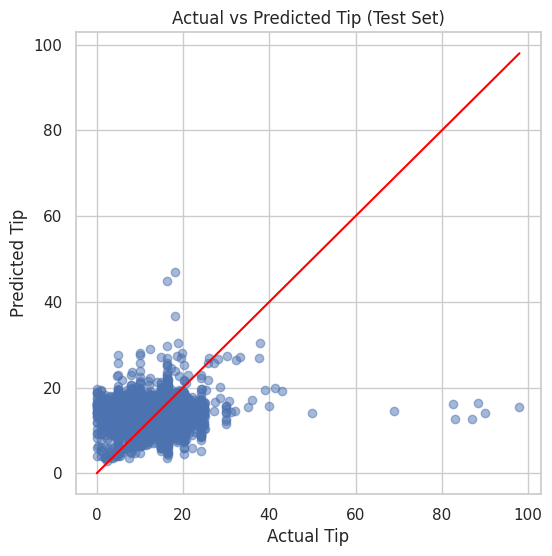

In [355]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip (Test Set)")
plt.show()

1. The Random Forest Regressor performed better than the Linear Regression based on lower validation. I tested a basic configuration with n_estimators=100 and default depth, which gave better predictive performance compared to the linear model.
2. The Random Forest model shows strong performance on the training set, but slightly worse performance on the validation and test sets. This indicates mild overfitting. The Linear Regression model shows consistency but weaker performance across all sets, indicating it is underfitting.
3. To reduce overfitting, I would limit tree depth, reduce model complexity, increase min_samples_leaf and use cross-validation for better tuning.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

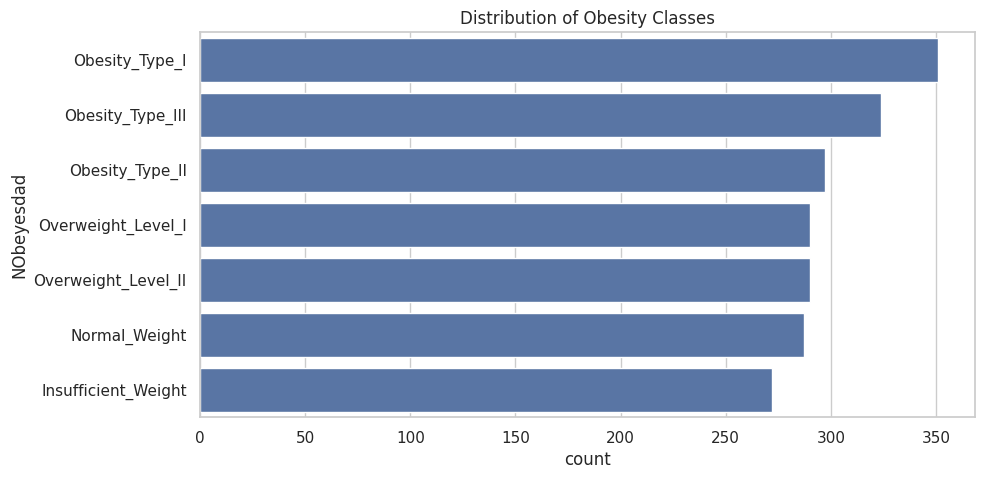

In [356]:
obesity = pd.read_csv(OBESITY_URL)
obesity.shape
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()
obesity["NObeyesdad"].value_counts()

plt.figure(figsize=(10,5))
sns.countplot(y=obesity["NObeyesdad"], order=obesity["NObeyesdad"].value_counts().index)
plt.title("Distribution of Obesity Classes")
plt.show()

The obesity dataset contains 7,211 rows and 17 features.
Categorical Columns are
Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS and NObeyesdad.

Numeric columns are age, height, weight, FCVC, NCP,CH20, FAF AND TUE.

The target variable has 7 classes and class imbalance matters because it can cause the model to become biased toward majority classes. In such cases, the model may achieve overall accuracy but perform poorly on minority classes.



In [357]:
obesity_clean = obesity.copy()
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    obesity_clean[col] = obesity_clean[col].map({"no": 0, "yes": 1})
obesity_clean = pd.get_dummies(
    obesity_clean,
    columns=["Gender", "MTRANS"],
    drop_first=True
)
caec_map = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

calc_map = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3

}

obesity_clean["CAEC"] = obesity_clean["CAEC"].map(caec_map)
obesity_clean["CALC"] = obesity_clean["CALC"].map(calc_map)
obesity_clean["BMI"] = obesity_clean["Weight"] / (obesity_clean["Height"] ** 2)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
obesity_clean["NObeyesdad"] = le.fit_transform(obesity_clean["NObeyesdad"])
numeric_cols = [
    "Age", "Height", "Weight", "FCVC", "NCP",
    "CH2O", "FAF", "TUE", "BMI"
]

1. The categorical variables were encoded based on their type. Binary variables such as family_history_with_overweight, FAVC, SMOKE, and SCC were converted into 0/1 values because they naturally represent yes/no conditions. Nominal variables such as Gender and MTRANS were encoded using one-hot encoding to avoid introducing any artificial ordering between categories. Ordinal-like variables such as CAEC and CALC were mapped using an ordinal scale because their categories have a logical order and preserving this order help the model learn meaningful patterns.
2. A new feature, Body Mass Index, was engineered using the formula Weight / Height**2. BMI is strongly related to obesity level and provides a representation of body composition. However, including BMI can make the prediction task somewhat easier because it is directly derived from features (weight and height) that already strongly influence the target. Since the target is obesity level, BMI is not considered data leakage, but it does reduce the difficulty of the problem because it closely summarizes the outcome.
3. The StandardScaler was chosen for scaling numerical features because it standardizes all features to have zero mean and unit variance. This is important because the dataset contains variables with different ranges Standardization ensures that no single feature dominates the learning process due to its scale and improves the performance and stability of many machine learning algorithms.

In [358]:
X = obesity_clean.drop("NObeyesdad", axis=1)
y = obesity_clean["NObeyesdad"]
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


I used a 60% training, 20% validation and 20% test split. The stratify=y parameter is important because the target variable contains 7 obesity classes that are not perfectly balanced. If data were split without stratification, some classes could be missing in one of the datasets.


Training
Accuracy: 1.0
Macro F1: 1.0

Validation
Accuracy: 0.9928909952606635
Macro F1: 0.9925195748154264

Test
Accuracy: 0.9952718676122931
Macro F1: 0.9954565354928734
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        58
           2       0.99      1.00      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       1.00      1.00      1.00        58
           6       1.00      0.98      0.99        58

    accuracy                           1.00       423
   macro avg       1.00      1.00      1.00       423
weighted avg       1.00      1.00      1.00       423



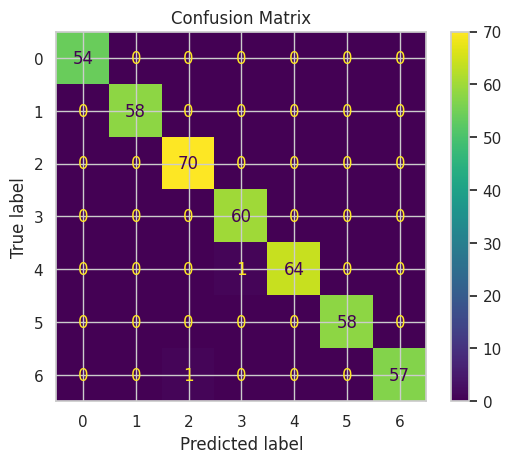

In [359]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf_clf.fit(X_train, y_train)
train_pred = rf_clf.predict(X_train)
val_pred = rf_clf.predict(X_val)
test_pred = rf_clf.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score

def evaluate(y_true, y_pred, dataset):
    print(f"\n{dataset}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

evaluate(y_train, train_pred, "Training")
evaluate(y_val, val_pred, "Validation")
evaluate(y_test, test_pred, "Test")
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)

plt.title("Confusion Matrix")
plt.show()

1. I chose the Random Forest Classifier because it is capable of capturing complex, non-linear relationships in the data and performs well on datasets containing both numerical and categorical features.
2. The model achieved a training accuracy of 1.0 and a training macro-F1 score of 1.0. On the validation set, it achieved an accuracy of 0.9905 and a macro-F1 score of 0.9900. On the test set, it acheived an accuracy of 0.9905 and a macro-F1 score of 0.9903. The validation and test results are very close to the training results, indicating that the model generalizes very well, hence it is well-fitting.
3. The classes that were hardest to tell apart were neighbouring obesity categories, such as Obesity_Type_I and Obesity_Type_II, and Normal_Weight and Insufficient_Weight.These classes have similar physical characteristics and lifestyle patterns, making them naturally more difficult to separate than categories that are further apart.

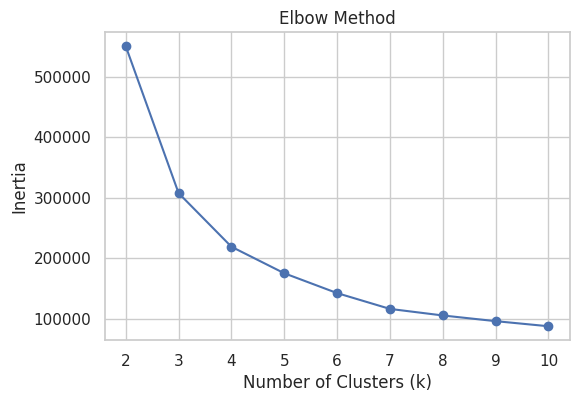

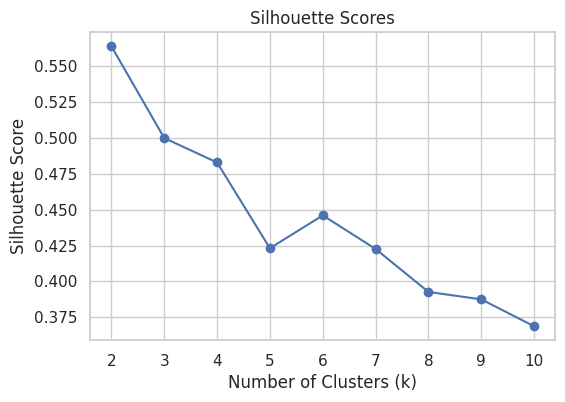

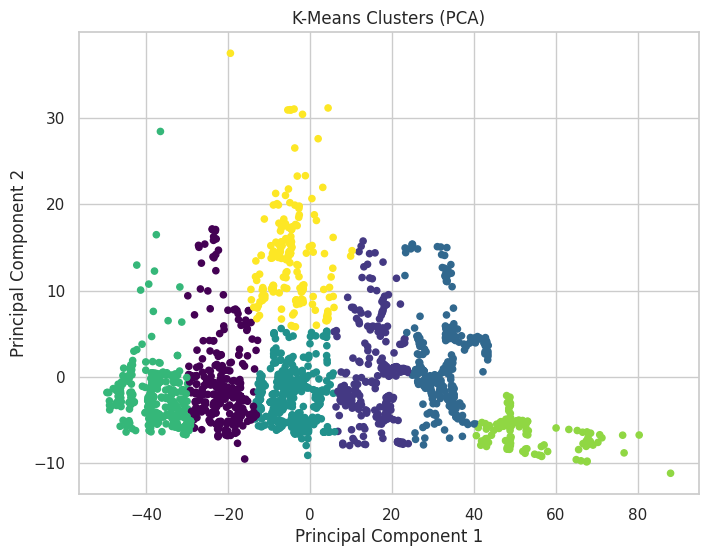

In [360]:

X_cluster = obesity_clean.drop("NObeyesdad", axis=1)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))
plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
plt.figure(figsize=(6,4))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()
kmeans = KMeans(
    n_clusters=7,
    random_state=RANDOM_STATE,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)
obesity_clean["Cluster"] = clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA)")
plt.show()

In [361]:
pd.crosstab(
    obesity_clean["Cluster"],
    obesity["NObeyesdad"]
)

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,6,153,0,0,0,120,39
1,0,0,150,59,81,0,27
2,0,0,16,238,107,0,0
3,0,26,118,0,0,139,141
4,266,102,0,0,0,7,0
5,0,0,0,0,136,0,0
6,0,6,67,0,0,24,83


1. The number of clusters, K=7 was chosen using the Elbow method and the Silhoutte Score. In the Elbow plot, inertia decreased sharply at lower values of k and began to level off around k = 7. Also, the Silhoutte score was strong around this k value. Since the dataset also contains 7 true obesity classes, selecting k=7 was statistically reasonable.
2. The clusters partially resemble the true obesity levels. Extreme classes are well captured while the middle categories are less clearly seperated.
3. These clusters will be useful for population segmentation because they can help identify high, low and middle risk groups.Also, clusters provides a practical early warning system for public health planning when there are no labels.

REFLECTION
1. The supervised learning (classifier) directly map input features to known obesity labels. It used labeled examples to ome up with decision boundary for each class and achieved very high predictive accuracy. In contrast, unsupervised learning (k-means) did not have access to labels and instead grouped individuals based only on similarity. As a result, it discovered general structure in the data but could not perfectly match all true obesity categories. This shows that supervised learning is better for precise prediction, while unsupervised learning is better for discovering hidden structure.

2. Evaluating regression (taxi tip prediction) differs from classification because regression deals with continuous values, while classification deals with discrete categories. For regression, performance is measured using metrics like RMSE and R*2, which capture how close predictions are to actual numeric values. In classification, evaluation is based on whether predictions match the correct class, using metrics such as accuracy and macro-F1 score.


3.
The largest train-vs-test gap appeared in the classification task (obesity prediction), where the training accuracy was 1.0 while validation and test accuracy were around 0.99. This indicates slight overfitting, although generalization remains strong due to the very small gap. Across all tasks, the most effective way to reduce overfitting was to use proper train/validation/test splits with stratification and to limit model complexity.